# Support Vector Machine

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

from sklearn.datasets import make_blobs, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from models.svm import SVM

from metrics.classification import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from utils.plots import plot_decision_boundary
from utils.tests import parameter_sweep_classification

## Dataset

In [3]:
# generation
X, y = make_blobs(
    n_samples=500,
    centers=2,
    cluster_std=1.2,
    random_state=42,
)

# convert labels
y_svm = np.where(y == 0, -1, 1)

# splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_svm,
    test_size=0.2,
    random_state=42,
    stratify=y_svm,
)

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

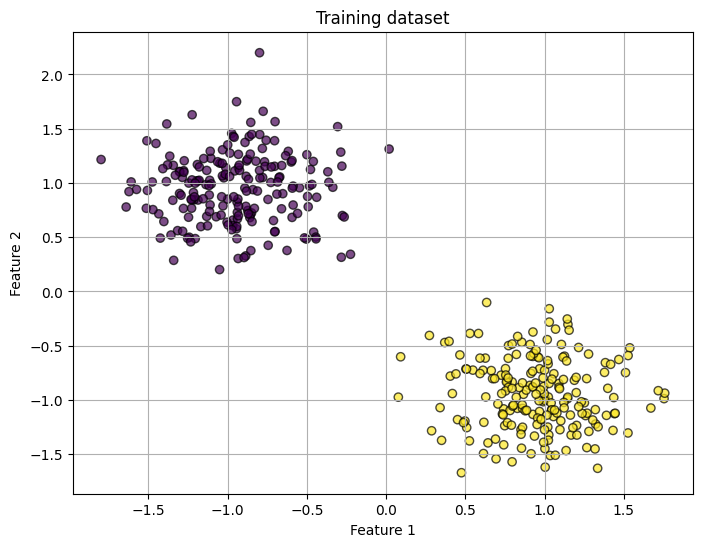

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

## Comparison with `sklearn` model

In [5]:
# own model
scratch_svm = SVM(
    lr=0.001,
    lambda_param=0.01,
    n_iters=1000,
)

start = perf_counter()
scratch_svm.fit(X_train_scaled, y_train)
scratch_fit_time = perf_counter() - start

start = perf_counter()
scratch_preds = scratch_svm.predict(X_test_scaled)
scratch_predict_time = perf_counter() - start

# sklearn model
sklearn_svm = SVC(
    kernel="linear",
    C=1.0,
)

start = perf_counter()
sklearn_svm.fit(X_train_scaled, y_train)
sklearn_fit_time = perf_counter() - start

start = perf_counter()
sklearn_preds = sklearn_svm.predict(X_test_scaled)
sklearn_predict_time = perf_counter() - start

### Results

In [6]:
results = {
    "From scratch": {
        "Accuracy": accuracy_score(y_test, scratch_preds),
        "Precision": precision_score(y_test, scratch_preds),
        "Recall": recall_score(y_test, scratch_preds),
        "F1": f1_score(y_test, scratch_preds),
        "Fit time": scratch_fit_time,
        "Predict time": scratch_predict_time,
    },
    "Scikit-learn": {
        "Accuracy": accuracy_score(y_test, sklearn_preds),
        "Precision": precision_score(y_test, sklearn_preds),
        "Recall": recall_score(y_test, sklearn_preds),
        "F1": f1_score(y_test, sklearn_preds),
        "Fit time": sklearn_fit_time,
        "Predict time": sklearn_predict_time,
    },
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,Fit time,Predict time
From scratch,1.0,1.0,1.0,1.0,1.775270,0.000146
Scikit-learn,1.0,1.0,1.0,1.0,0.005474,0.001182


## Plots 

### Loss Curves

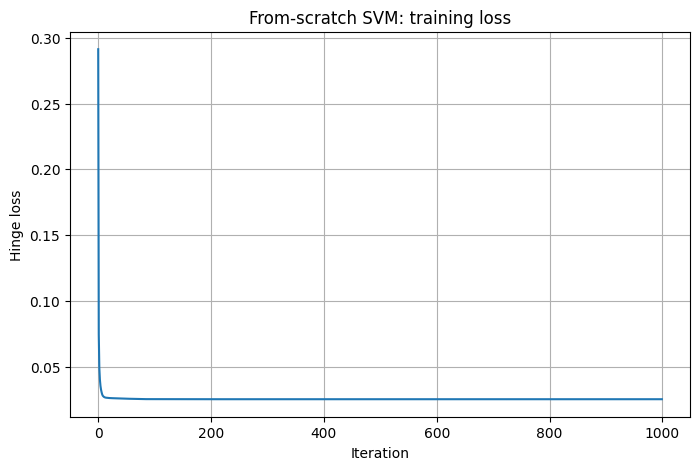

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(scratch_svm.loss_history)

plt.xlabel("Iteration")
plt.ylabel("Hinge loss")
plt.title("From-scratch SVM: training loss")
plt.grid(True)

plt.show()

## Decision Boundaries
We can see that although the plots look similar, the slope of the hyperplane (thus of the margins) is slightly different. That is because the loss function used by the `sklearn` implementation is 
$$
{\displaystyle \lVert \mathbf {w} \rVert ^{2}+C\left[{\frac {1}{n}}\sum _{i=1}^{n}\max \left(0,1-y_{i}(\mathbf {w} ^{\mathsf {T}}\mathbf {x} _{i}-b)\right)\right]}
$$
While the one we used in our implementation is
$$
\lambda\|w\|^2+\frac1n\sum_{i=1}^n\max\left(0, 1-y_i(w\cdot x_i-b)\right) 
$$
And our $\lambda$ parameter is not directly equal to `sklearn`'s $C$. Also, our model uses SGD-style updates, while sklearn's model is more optimized, and the stopping criteria also differ.

Both models learn essentially the same separating geometry, but the exact margin orientation differs slightly because the optimization formulations and hyperparameter scales are not identical.

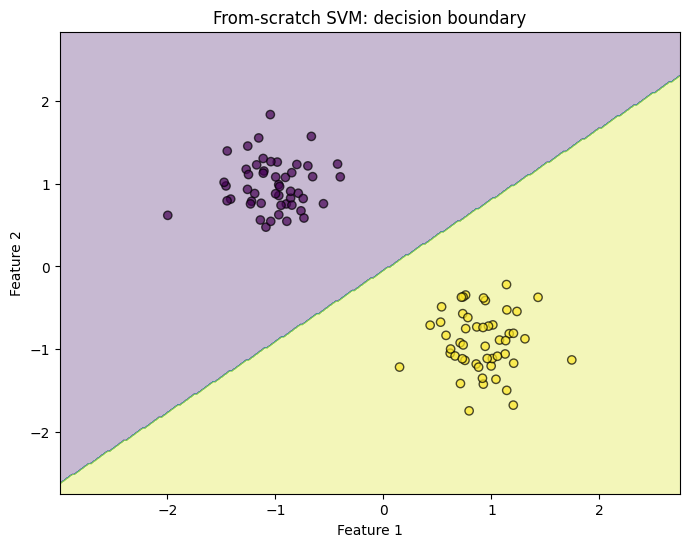

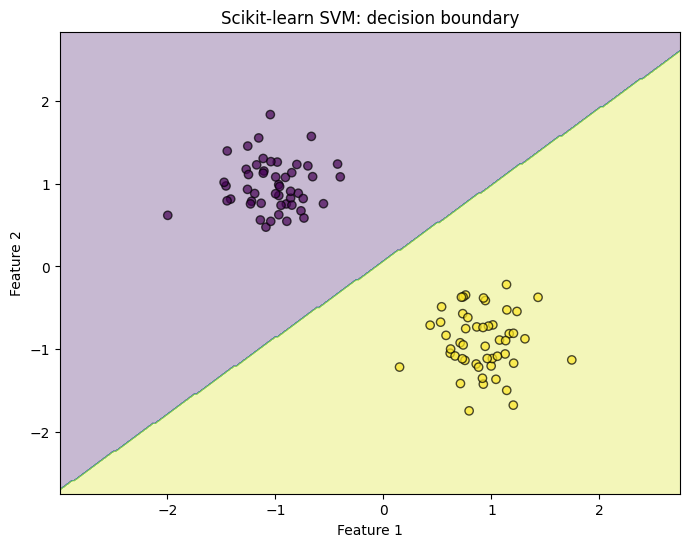

In [8]:
plot_decision_boundary(
    scratch_svm,
    X_test_scaled,
    y_test,
    "From-scratch SVM: decision boundary"
)

plot_decision_boundary(
    sklearn_svm,
    X_test_scaled,
    y_test,
    "Scikit-learn SVM: decision boundary"
)

## Harder Dataset

In [9]:
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    class_sep=0.8,
    flip_y=0.05,
    random_state=42,
)

In [10]:
# convert labels
y_svm = np.where(y == 0, -1, 1)

# splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_svm,
    test_size=0.2,
    random_state=42,
    stratify=y_svm,
)

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

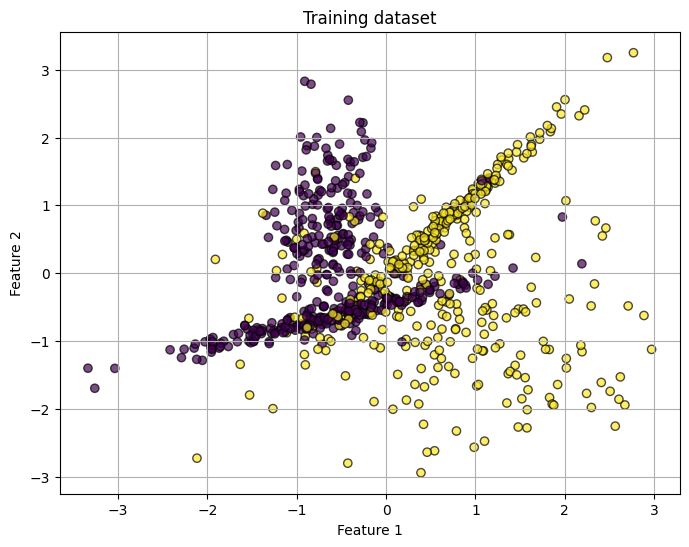

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

### Hyperparameter Sweeps

#### $\lambda$ Parameter

We have that
- small lambda:
    - weaker regularization
    - model cares more about classification errors
    - boundary may rotate to fit difficult points

- large lambda:
    - stronger regularization
    - model penalizes large weights more
    - boundary becomes more conservative

Basically, larger lambda → stronger penalty on large weights → stronger preference for wider margin → more underfitting risk. Strong regularization shrinks/degenerates the model, so it becomes conservative about predicting the positive class.

We can also see that at higher lambdas, precision briefly rises to 1 before plummeting. At these values, the model predicts very few positives, but all of them are correct, giving a high precision value. However, since it misses most real positives, recall and F1 collapse.

For even larger lambdas, the model predicts no positives, so by the convention used precision falls to 0, as do recall and F1, while accuracy is around 0.5.

My linear SVM implementation however cannot hope to reach higher accuracy on this dataset, because the two classes cannot be separated with a linear separator. We would obtain better results using the SVM from `sklearn` with the `rbf` kernel, as shown below.

##### Scratch SVM

In [12]:
lambda_values = np.logspace(-4, 1, 50)

sweep_results, loss_curves, models = parameter_sweep_classification(
    model_cls=SVM, 
    param_grid={
        'lambda_param': lambda_values
    }, 
    X_train=X_train_scaled, 
    y_train=y_train, 
    X_test=X_test_scaled, 
    y_test=y_test, 
    base_params={'n_iters':1000, 'lr':0.01})

sweep_df = pd.DataFrame(sweep_results)

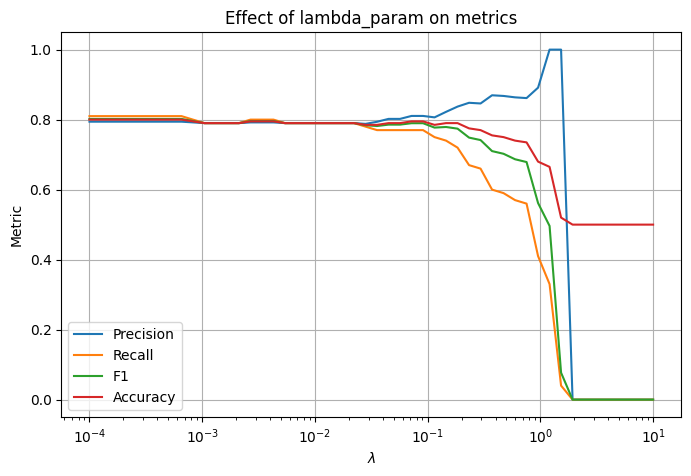

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(sweep_df["lambda_param"], sweep_df["test_precision"], label="Precision")
plt.plot(sweep_df["lambda_param"], sweep_df["test_recall"], label="Recall")
plt.plot(sweep_df["lambda_param"], sweep_df["test_f1"], label="F1")
plt.plot(sweep_df["lambda_param"], sweep_df["test_accuracy"], label="Accuracy")

plt.xlabel(r"$\lambda$")
plt.ylabel("Metric")
plt.xscale("log")
plt.title("Effect of lambda_param on metrics")
plt.legend()
plt.grid(True)

plt.show()

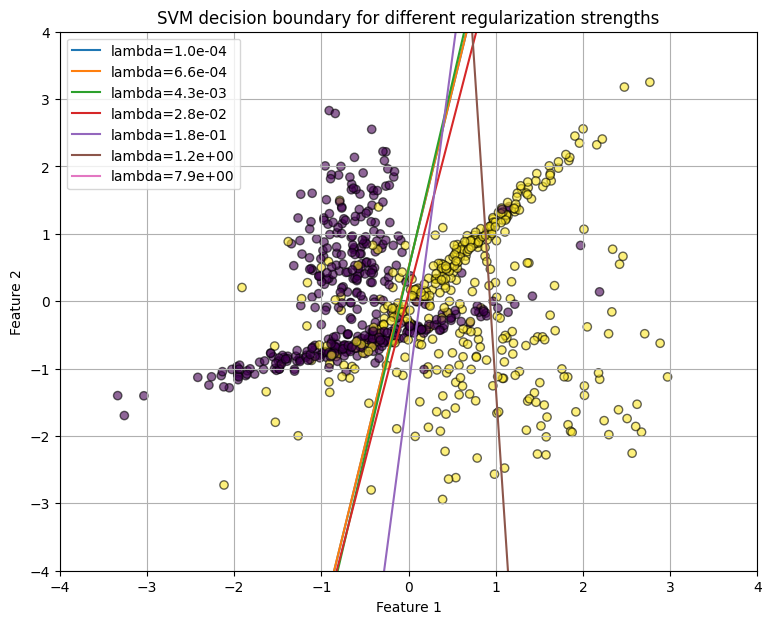

In [14]:
plt.figure(figsize=(9, 7))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.6,
)

x_vals = np.linspace(
    X_train_scaled[:, 0].min() - 0.5,
    X_train_scaled[:, 0].max() + 0.5,
    300,
)

i = 0
for lambda_param, model in models.items():

    if i%8 != 0:
        i+=1
        continue

    w = model.w
    b = model.b

    if np.isclose(w[1], 0):
        continue

    y_vals = (b - w[0] * x_vals) / w[1]

    plt.plot(
        x_vals,
        y_vals,
        label=f"lambda={lambda_param[0]:.1e}",
    )

    i+=1

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM decision boundary for different regularization strengths")
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.legend()
plt.grid(True)

plt.show()

##### `sklearn` SVM

In [22]:
sklearn_svm = SVC(
    kernel="rbf",
    C=1.0,
)

sklearn_svm.fit(X_train_scaled, y_train)
sklearn_preds = sklearn_svm.predict(X_test_scaled)

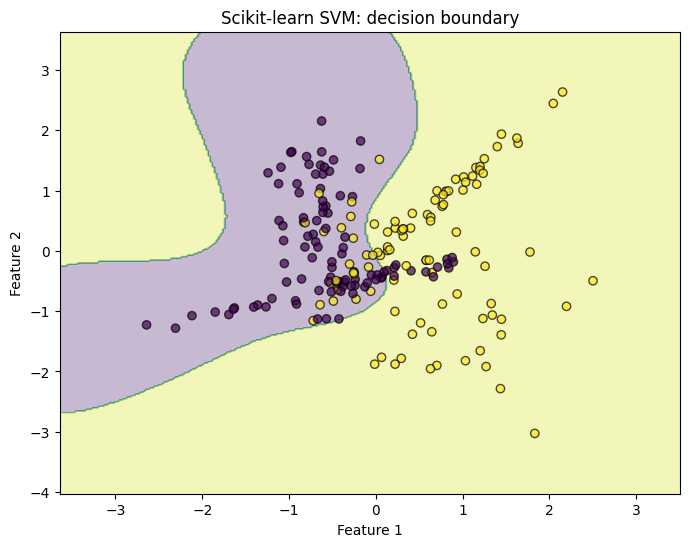

In [23]:
plot_decision_boundary(
    sklearn_svm,
    X_test_scaled,
    y_test,
    "Scikit-learn SVM: decision boundary"
)

In [24]:
results = {
    "Scikit-learn": {
        "Accuracy": accuracy_score(y_test, sklearn_preds),
        "Precision": precision_score(y_test, sklearn_preds),
        "Recall": recall_score(y_test, sklearn_preds),
        "F1": f1_score(y_test, sklearn_preds),
        "Fit time": sklearn_fit_time,
        "Predict time": sklearn_predict_time,
    },
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,Fit time,Predict time
Scikit-learn,0.815,0.846154,0.77,0.806283,0.005474,0.001182
